# 01 - testing

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=0.0, res_width=1280,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [5]:
scene_dataset.point_cloud.rgb.shape

(241367, 3)

In [6]:
np.median(scene_dataset.point_cloud.positions, axis=0), (np.max(scene_dataset.point_cloud.positions, axis=0) - np.min(scene_dataset.point_cloud.positions, axis=0)), np.min(scene_dataset.point_cloud.positions, axis=0)

(array([-0.12122369,  1.67219017,  1.53192803]),
 array([39.8653489 , 44.4045387 , 69.77396625]),
 array([-21.84321869, -26.09001815, -22.10813442]))

In [16]:
shift = np.array([30.0, 30.0, 30.0])
level = 10
scale = float(2**level)/100.0
point_cloud_init = (scene_dataset.point_cloud.positions + shift) * scale
point_cloud_rgbs = scene_dataset.point_cloud.rgb
point_cloud_init[:10]

array([[312.01291969, 335.28663458, 311.70407471],
       [312.26266536, 336.03870354, 310.76688602],
       [312.86739444, 337.68689015, 308.75365123],
       [310.97525251, 333.39316788, 314.10459538],
       [306.17189893, 321.94451535, 328.42657643],
       [312.3542034 , 336.9889545 , 309.68022148],
       [304.49935372, 318.37699519, 332.98324237],
       [307.8237124 , 326.25855144, 323.02254372],
       [310.72174944, 333.11342417, 314.39504598],
       [311.98946941, 336.36270164, 310.39003782]])

In [17]:
point_cloud_voxelized, correspon_old_ind =  np.unique(np.floor(point_cloud_init), axis=0, return_inverse=True)

N = point_cloud_voxelized.shape[0]
rgb_sum, rgb_count = np.zeros((N, 3), dtype=np.float32), np.zeros((N, 3), dtype=np.float32)
for ind_old, ind_new in enumerate(correspon_old_ind):
    rgb_sum[ind_new] += np.float32(point_cloud_rgbs[ind_old])
    rgb_count[ind_new] += 1

point_cloud_voxelized_rgb = rgb_sum / rgb_count

point_cloud_voxelized[:10], point_cloud_voxelized_rgb[:10]


(array([[ 83., 449., 239.],
        [ 91., 368., 368.],
        [132., 376., 230.],
        [135., 389., 226.],
        [137., 389., 228.],
        [138., 383., 223.],
        [138., 388., 229.],
        [141., 390., 225.],
        [143., 385., 232.],
        [144., 396., 242.]]),
 array([[ 94., 101., 129.],
        [ 11.,  10.,   6.],
        [246., 255., 254.],
        [150., 153., 184.],
        [143., 144., 172.],
        [ 58.,  61.,  75.],
        [ 83.,  86., 106.],
        [ 54.,  53.,  61.],
        [104., 110., 139.],
        [ 40.,  38.,  44.]], dtype=float32))

In [18]:
morton_code = decompress_render.utils.position_to_mortoncode(
    torch.tensor(point_cloud_voxelized, dtype=torch.int64).cuda(),
    torch.tensor([10], dtype=torch.int8).cuda(), 
).cpu().numpy()

vox_rgb = point_cloud_voxelized_rgb/255.0
vox_root = point_cloud_voxelized / scale - shift
vox_length = np.array([1/scale])

# vox_root, vox_length, vox_rgb
vox_root.shape, vox_length.shape, vox_rgb.shape, morton_code.shape

((10885, 3), (1,), (10885, 3), (10885, 1))

In [19]:
point_cloud_voxelized

array([[ 83., 449., 239.],
       [ 91., 368., 368.],
       [132., 376., 230.],
       ...,
       [485., 276., 399.],
       [489., 269., 425.],
       [491., 286., 386.]])

In [20]:
subtree_shift_int64 = torch.tensor([
    [0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1],
    [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1],
], dtype=torch.int64)
lv2max = 16 - level

base_grid_ijk = (torch.tensor(point_cloud_voxelized, dtype=torch.int64) << lv2max).view(-1, 1, 3)
gridpts = base_grid_ijk + (subtree_shift_int64 << lv2max).view(-1, 8, 3)

grid_pts_key, vox_key = np.unique(gridpts.reshape(-1, 3), axis=0, return_inverse=True)
grid_geo = np.ones((grid_pts_key.shape[0], 1), dtype=np.float32) * 0.44
vox_key = vox_key.reshape(-1, 8)

In [21]:
morton_code_tensor = torch.tensor(morton_code, dtype=torch.int64, device="cuda")
vox_roots_tensor = torch.tensor(vox_root, dtype=torch.float32, device="cuda")
vox_length_tensor = torch.tensor(vox_length, dtype=torch.float32, device="cuda")
vox2corners_tensor = torch.tensor(vox_key, dtype=torch.int64, device="cuda")
vox_params_geo_tensor = torch.tensor(grid_geo, dtype=torch.float32, device="cuda")
vox_params_color_tensor = torch.tensor(vox_rgb, dtype=torch.float32, device="cuda")

print(f"morton_code_tensor={morton_code_tensor.shape}")
print(f"vox_roots_tensor={vox_roots_tensor.shape}")
print(f"vox_length_tensor={vox_length_tensor.shape}")
print(f"vox2corners_tensor={vox2corners_tensor.shape}")
print(f"vox_params_geo_tensor={vox_params_geo_tensor.shape}")
print(f"vox_params_color_tensor={vox_params_color_tensor.shape}")

morton_code_tensor=torch.Size([10885, 1])
vox_roots_tensor=torch.Size([10885, 3])
vox_length_tensor=torch.Size([1])
vox2corners_tensor=torch.Size([10885, 8])
vox_params_geo_tensor=torch.Size([39234, 1])
vox_params_color_tensor=torch.Size([10885, 3])


In [22]:
a_view = train_views[0]
ss = 0.25

w_src, h_src = a_view.render_width, a_view.render_height
w, h = round(w_src * ss), round(h_src * ss)
w_ss, h_ss = w / w_src, h / h_src


camera_settings = decompress_render.renderer.CameraSettings(
    image_width=w, 
    image_height=h, 
    tanfovx=a_view.tanfovx, 
    tanfovy=a_view.tanfovy, 
    cx=a_view.cx * w_ss,
    cy=a_view.cy * h_ss,
    w2c_matrix=a_view.world2view.cuda(),
    c2w_matrix=a_view.view2world.cuda()
)

render_settings = decompress_render.renderer.RenderSettings(
    num_sample_per_vox=3,
    bg_color=1.0,
    near=a_view.near,
    need_depth=True,
    track_max_w=False,
    debug=True,
)


In [23]:
(preprocessed, input_renderer, result_rendered) = decompress_render.renderer.rasterize_voxels_main(
    camera_settings=camera_settings,
    render_settings=render_settings,
    morton_code=morton_code_tensor,
    vox_roots=vox_roots_tensor,
    vox_length=vox_length_tensor,
    vox2corners=vox2corners_tensor,
    vox_params_geo=vox_params_geo_tensor,
    vox_params_color=vox_params_color_tensor,
)

N: 10885 


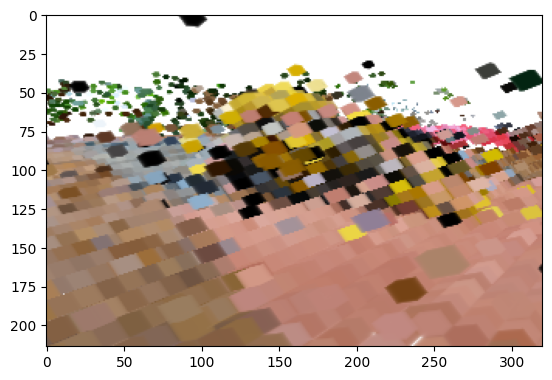

In [24]:
img_out = torch.permute(result_rendered[0], dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_out)

In [25]:
result_rendered[1][:1]

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [1.6738, 1.6764, 1.6789,  ..., 1.8528, 1.8522, 1.8466],
         [1.6693, 1.6707, 1.6733,  ..., 1.8455, 1.8384, 1.8333],
         [1.6653, 1.6676, 1.6702,  ..., 1.8341, 1.8285, 1.8246]]],
       device='cuda:0')

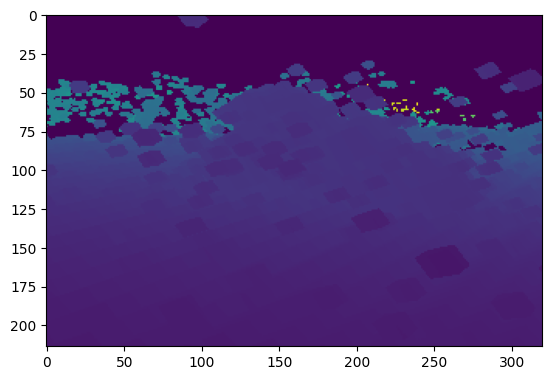

In [26]:
img_out = torch.permute(result_rendered[1][2:3, :, :], dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_out)

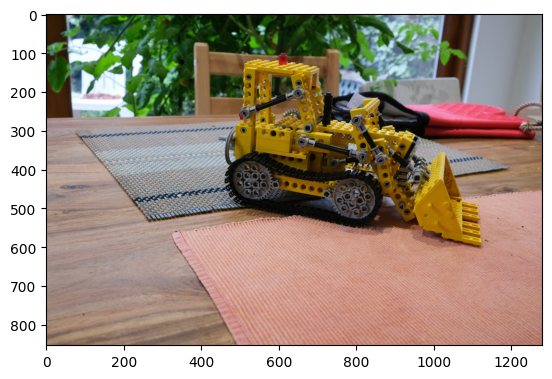

In [153]:
img_real = torch.permute(a_view.rendered_true, dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_real)

N: 124774 


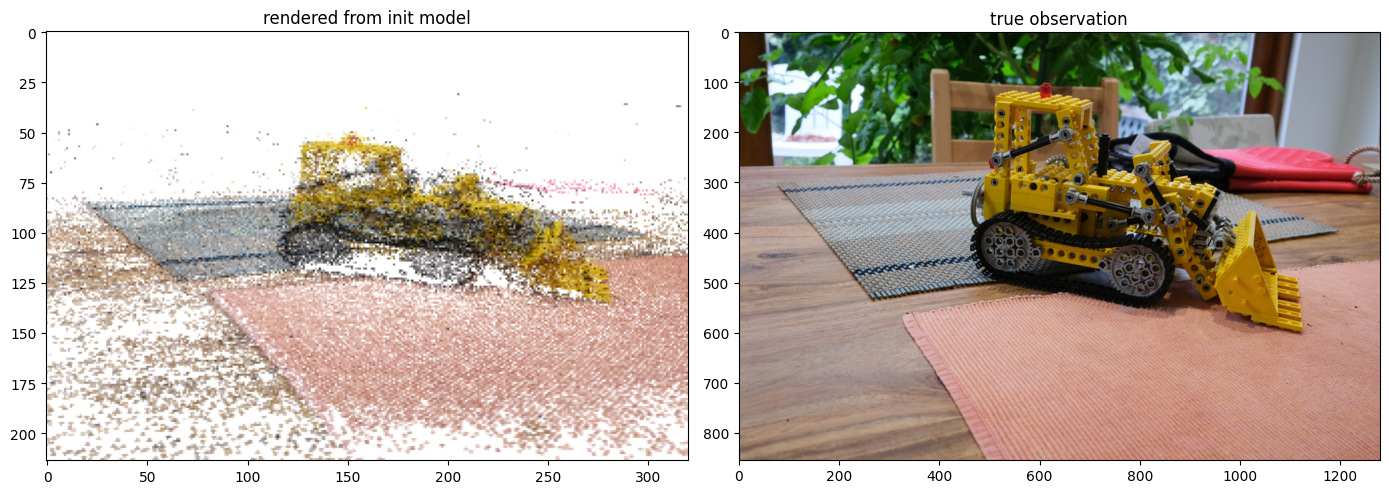

N: 124774 


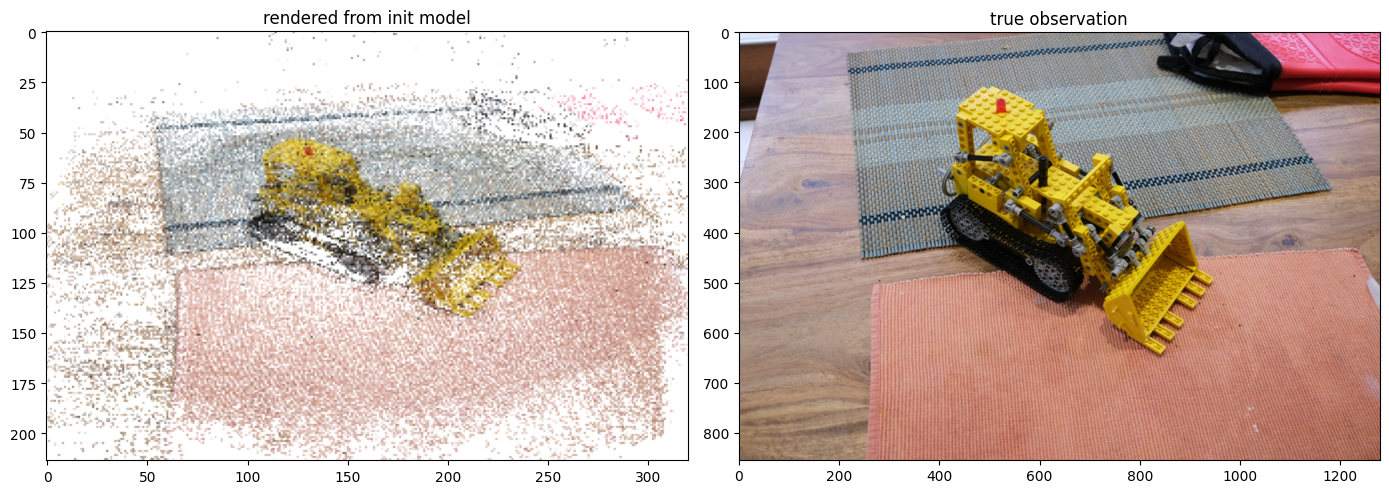

N: 124774 


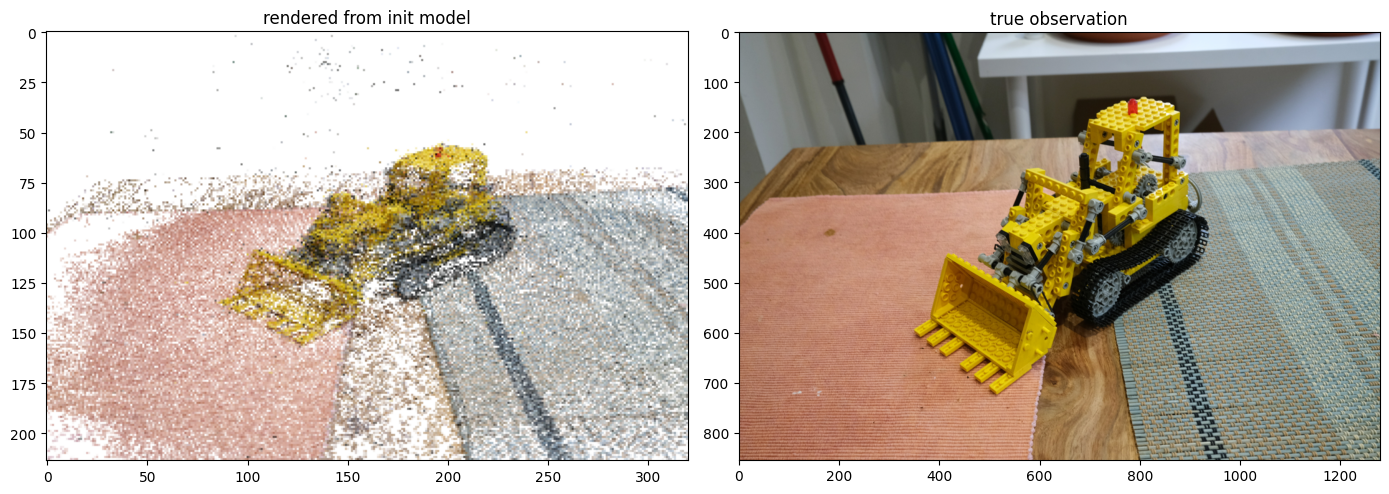

N: 124774 


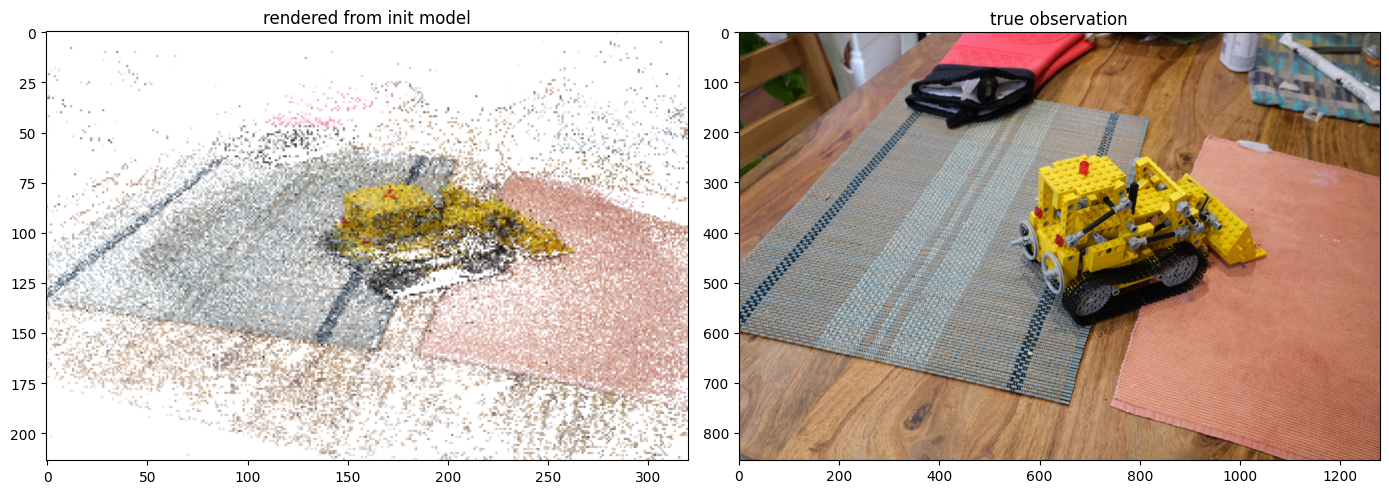

N: 124774 


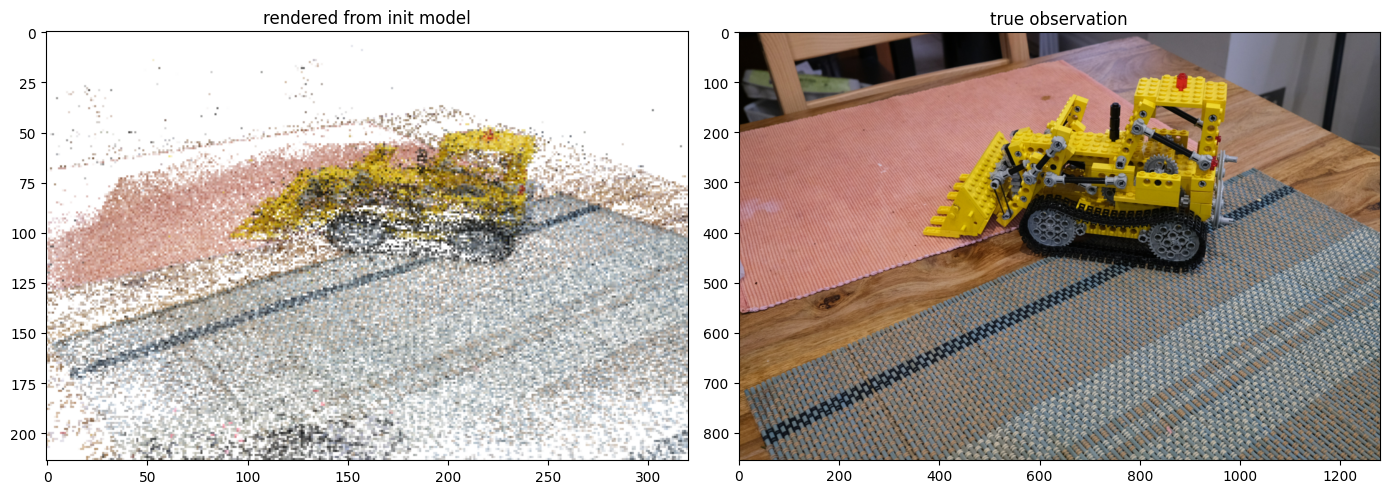

N: 124774 


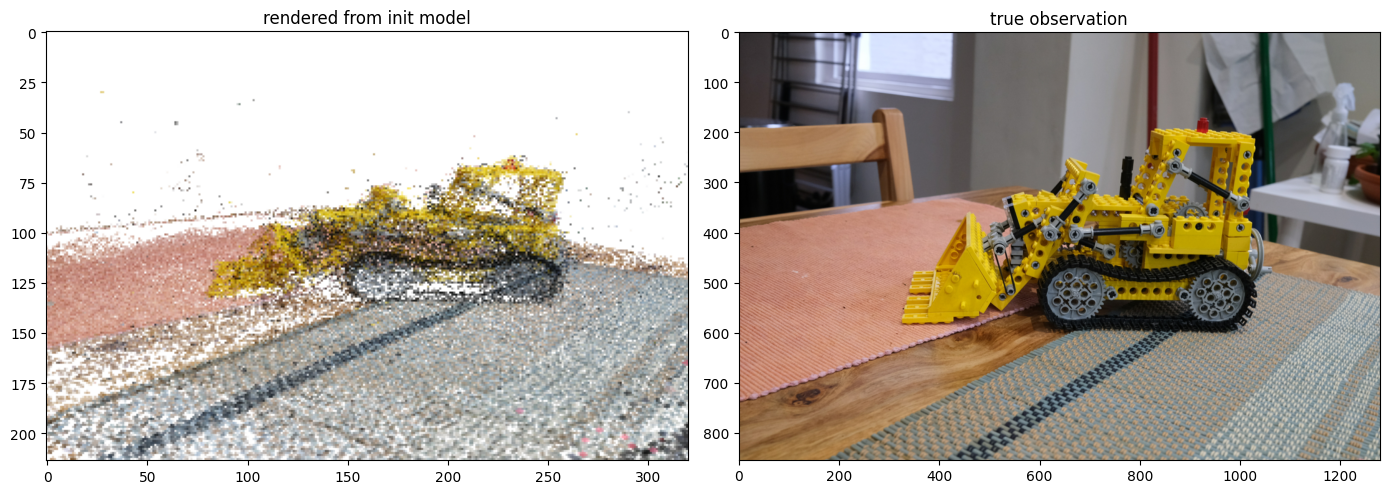

In [ ]:
for view_i in range(len(train_views)):
    if (view_i % 50 != 0):
        continue
    
    a_view = train_views[view_i]
    ss = 0.25

    w_src, h_src = a_view.render_width, a_view.render_height
    w, h = round(w_src * ss), round(h_src * ss)
    w_ss, h_ss = w / w_src, h / h_src


    camera_settings = decompress_render.renderer.CameraSettings(
        image_width=w, 
        image_height=h, 
        tanfovx=a_view.tanfovx, 
        tanfovy=a_view.tanfovy, 
        cx=a_view.cx * w_ss,
        cy=a_view.cy * h_ss,
        w2c_matrix=a_view.world2view.cuda(),
        c2w_matrix=a_view.view2world.cuda()
    )

    render_settings = decompress_render.renderer.RenderSettings(
        num_sample_per_vox=3,
        bg_color=1.0,
        near=a_view.near,
        need_depth=False,
        track_max_w=False,
        debug=True,
    )
        
    (preprocessed, input_renderer, result_rendered) = decompress_render.renderer.rasterize_voxels_main(
        camera_settings=camera_settings,
        render_settings=render_settings,
        morton_code=morton_code_tensor,
        vox_roots=vox_roots_tensor,
        vox_length=vox_length_tensor,
        vox2corners=vox2corners_tensor,
        vox_params_geo=vox_params_geo_tensor,
        vox_params_color=vox_params_color_tensor,
    )


    img_out = torch.permute(result_rendered[0], dims=(1, 2, 0)).detach().cpu().numpy()
    img_real = torch.permute(a_view.rendered_true, dims=(1, 2, 0)).detach().cpu().numpy()

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

    ax[0].imshow(img_out)
    ax[0].set_title(f"rendered from init model")
    ax[1].imshow(img_real)
    ax[1].set_title(f"true observation")

    # plt.suptitle(f"View_ID = {0}")
    plt.tight_layout()
    plt.show()

